In [ ]:
print("harekrishna")

harekrishna


In [ ]:
import os
import urllib.request

if not  os.path.exists("the-verdict.txt"):
    url = ("https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/refs/heads/main/ch02/01_main-chapter-code/the-verdict.txt")
    file_path = "the-verdict.txt"
    urllib.request.urlretrieve(url, file_path)

In [ ]:
with open("the-verdict.txt", 'r' ) as f:
    raw_text = f.read()

In [ ]:
raw_text

'I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no great surprise to me to hear that, in the height of his glory, he had dropped his painting, married a rich widow, and established himself in a villa on the Riviera. (Though I rather thought it would have been Rome or Florence.)\n\n"The height of his glory"--that was what the women called it. I can hear Mrs. Gideon Thwing--his last Chicago sitter--deploring his unaccountable abdication. "Of course it\'s going to send the value of my picture \'way up; but I don\'t think of that, Mr. Rickham--the loss to Arrt is all I think of." The word, on Mrs. Thwing\'s lips, multiplied its _rs_ as though they were reflected in an endless vista of mirrors. And it was not only the Mrs. Thwings who mourned. Had not the exquisite Hermia Croft, at the last Grafton Gallery show, stopped me before Gisburn\'s "Moon-dancers" to say, with tears in her eyes: "We shall not look upon its like again"?\n\nWell!--even 

In [ ]:
import re           # regular expression, no need to learn this, we are just using it now, later we'll dump it

text = "hare   krishna, hari bol."      
results = re.split(r'(\s)', text)
print(results)

['hare', ' ', '', ' ', '', ' ', 'krishna,', ' ', 'hari', ' ', 'bol.']


In [ ]:
results= re.split(r'([,.]|\s)', text)

In [ ]:
print(results)  # here we get punctuation as different entities

['hare', ' ', '', ' ', '', ' ', 'krishna', ',', '', ' ', 'hari', ' ', 'bol', '.', '']


In [ ]:
results= [item for item in results if item.strip()]
print(results)

['hare', 'krishna', ',', 'hari', 'bol', '.']


In [ ]:
# lets remove other special characters also

text = "hare krishna , h--aribol."      
results = re.split(r'([,.:;?_!"(\')]|--|\s)', text)
results= [item.strip() for item in results if item.strip()]       # 
print(results)

['hare', 'krishna', ',', 'h', '--', 'aribol', '.']


In [ ]:
text = "hare krishna , h--aribol."      
results = re.split(r'([,.:;?_!"(\')]|--|\s)', raw_text)
results= [item for item in results if item.strip()]
preprocessed = results
print(len(results))

4690


Converting these tokens into token ids

In [ ]:
preprocessed[:10]

['I',
 'HAD',
 'always',
 'thought',
 'Jack',
 'Gisburn',
 'rather',
 'a',
 'cheap',
 'genius']

In [ ]:
#lets find out the unique words
all_words= sorted(set(preprocessed))     #we know that set dont do sorting so we sorted on our own
vocab_size = len(all_words)
print(vocab_size)

1130


In [ ]:

vocab= {token : integer for integer, token in enumerate(all_words)}

In [ ]:
vocab

{'!': 0,
 '"': 1,
 "'": 2,
 '(': 3,
 ')': 4,
 ',': 5,
 '--': 6,
 '.': 7,
 ':': 8,
 ';': 9,
 '?': 10,
 'A': 11,
 'Ah': 12,
 'Among': 13,
 'And': 14,
 'Are': 15,
 'Arrt': 16,
 'As': 17,
 'At': 18,
 'Be': 19,
 'Begin': 20,
 'Burlington': 21,
 'But': 22,
 'By': 23,
 'Carlo': 24,
 'Chicago': 25,
 'Claude': 26,
 'Come': 27,
 'Croft': 28,
 'Destroyed': 29,
 'Devonshire': 30,
 'Don': 31,
 'Dubarry': 32,
 'Emperors': 33,
 'Florence': 34,
 'For': 35,
 'Gallery': 36,
 'Gideon': 37,
 'Gisburn': 38,
 'Gisburns': 39,
 'Grafton': 40,
 'Greek': 41,
 'Grindle': 42,
 'Grindles': 43,
 'HAD': 44,
 'Had': 45,
 'Hang': 46,
 'Has': 47,
 'He': 48,
 'Her': 49,
 'Hermia': 50,
 'His': 51,
 'How': 52,
 'I': 53,
 'If': 54,
 'In': 55,
 'It': 56,
 'Jack': 57,
 'Jove': 58,
 'Just': 59,
 'Lord': 60,
 'Made': 61,
 'Miss': 62,
 'Money': 63,
 'Monte': 64,
 'Moon-dancers': 65,
 'Mr': 66,
 'Mrs': 67,
 'My': 68,
 'Never': 69,
 'No': 70,
 'Now': 71,
 'Nutley': 72,
 'Of': 73,
 'Oh': 74,
 'On': 75,
 'Once': 76,
 'Only': 77,
 '

In [ ]:
print(vocab.items())

dict_items([('!', 0), ('"', 1), ("'", 2), ('(', 3), (')', 4), (',', 5), ('--', 6), ('.', 7), (':', 8), (';', 9), ('?', 10), ('A', 11), ('Ah', 12), ('Among', 13), ('And', 14), ('Are', 15), ('Arrt', 16), ('As', 17), ('At', 18), ('Be', 19), ('Begin', 20), ('Burlington', 21), ('But', 22), ('By', 23), ('Carlo', 24), ('Chicago', 25), ('Claude', 26), ('Come', 27), ('Croft', 28), ('Destroyed', 29), ('Devonshire', 30), ('Don', 31), ('Dubarry', 32), ('Emperors', 33), ('Florence', 34), ('For', 35), ('Gallery', 36), ('Gideon', 37), ('Gisburn', 38), ('Gisburns', 39), ('Grafton', 40), ('Greek', 41), ('Grindle', 42), ('Grindles', 43), ('HAD', 44), ('Had', 45), ('Hang', 46), ('Has', 47), ('He', 48), ('Her', 49), ('Hermia', 50), ('His', 51), ('How', 52), ('I', 53), ('If', 54), ('In', 55), ('It', 56), ('Jack', 57), ('Jove', 58), ('Just', 59), ('Lord', 60), ('Made', 61), ('Miss', 62), ('Money', 63), ('Monte', 64), ('Moon-dancers', 65), ('Mr', 66), ('Mrs', 67), ('My', 68), ('Never', 69), ('No', 70), ('Now

very simple tokenizer, not used in real cases

In [ ]:
# now we have to voab, now lets tokenise into token ids
class SimpleTokenizerV1:
    def __init__(self, vocab):
        self.str_to_int = vocab
        self.int_to_str = {i:s for s,i in vocab.items()}

    def encode(self,text):
        preprocessed = re.split(r'([,.:;?_!"(\')]|--|\s)', text)

        preprocessed = [item.strip() for item in preprocessed if item.strip()]
        ids = [self.str_to_int[s] for s in preprocessed]
        return ids
    
    def decode(self,ids):
        text = " ".join([self.int_to_str[i] for i in ids])
        #replace spaces before the specified punctuations
        text = re.sub(r'\s+([,.?!"()\'])', r'\1', text)  # this removes the spaces before the punctuations
        # in the above step we put spaces everywhere after every token
        return text

In [ ]:
text = """I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow"""

In [ ]:
tokenizer= SimpleTokenizerV1(vocab)

In [ ]:
ids = tokenizer.encode(text)
ids

[53, 44, 149, 1003, 57, 38, 818, 115, 256, 486, 6, 1002, 115, 500, 435]

In [ ]:
tokenizer.decode(ids)

'I HAD always thought Jack Gisburn rather a cheap genius -- though a good fellow'

In [ ]:
tokenizer.decode(tokenizer.encode(text))  # it means this only tokenizer.decode(ids)

'I HAD always thought Jack Gisburn rather a cheap genius -- though a good fellow'

Special Tokens- unknown words, end of text...

In [ ]:
text1= "hare krishna"

In [ ]:
tokenizer.encode(text1) # problem is that hare is not in the vocab

KeyError: 'hare'

In [ ]:
all_tokens = sorted(list(set(preprocessed)))
all_tokens[:10]

['!', '"', "'", '(', ')', ',', '--', '.', ':', ';']

In [ ]:
haribol= sorted(set(preprocessed))
print(type(haribol))

<class 'list'>


In [ ]:
all_tokens.extend(["<|endoftext|>", "<|unk|>"])
vocab = {token: integer for integer, token in enumerate(all_tokens)}

In [ ]:
len(vocab)   #increased by 2 

1132

In [ ]:
for i, item in enumerate(list(vocab.items())[-5:]):   #to print the last 5 we converted this dict to list coz we cannot print the last 5 of dict
    print(item)

('younger', 1127)
('your', 1128)
('yourself', 1129)
('<|endoftext|>', 1130)
('<|unk|>', 1131)


In [ ]:
# now we have to voab, now lets tokenise into token ids
class SimpleTokenizerV2:
    def __init__(self, vocab):
        self.str_to_int = vocab
        self.int_to_str = {i:s for s,i in vocab.items()}

    def encode(self,text):
        preprocessed = re.split(r'([,.:;?_!"(\')]|--|\s)', text)

        preprocessed = [
            item.strip() for item in preprocessed if item.strip() 
            ]
        preprocessed = [
            item if item in self.str_to_int
            else "<|unk|>" for item in preprocessed
        ]
        ids = [self.str_to_int[s] for s in preprocessed]
        return ids
    
    def decode(self,ids):
        text = " ".join([self.int_to_str[i] for i in ids])
        #replace spaces before the specified punctuations
        text = re.sub(r'\s+([,.?!"()\'])', r'\1', text)  # this removes the spaces before the punctuations
        # in the above step we put spaces everywhere after every token
        return text

In [ ]:
tokeniser2= SimpleTokenizerV2(vocab)

In [ ]:
tokeniser2.encode(text)

[53, 44, 149, 1003, 57, 38, 818, 115, 256, 486, 6, 1002, 115, 500, 435]

In [ ]:
tokeniser2.decode(tokeniser2.encode(text))

'I HAD always thought Jack Gisburn rather a cheap genius -- though a good fellow'

but there is problem is that we dont know what were these unknowns originally

# BYTEPAIR encoding 

will take our tokeniser to next level
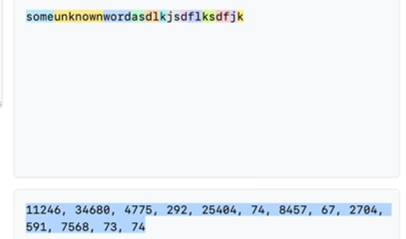

we will be using tiktoken library...coz if we code the bytepair encoding, we'll deviate from the actual goal, its a vast topic. 
Also this library is a python wrapper around rust code, so very fast

In [ ]:
import tiktoken  #gpt 2 style tokeniser ⭐



In [ ]:
tiktoken.__version__

'0.13.0'

In [ ]:
tokenizer = tiktoken.get_encoding("gpt2")

In [ ]:
tokenizer.encode("Hare krishna")

[39, 533, 479, 37518, 2616]

In [ ]:
tokenizer.decode(tokenizer.encode("Hare krishna"))

'Hare krishna'

In [ ]:
dir(tokenizer)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_core_bpe',
 '_encode_bytes',
 '_encode_only_native_bpe',
 '_encode_single_piece',
 '_mergeable_ranks',
 '_pat_str',
 '_special_token_values',
 '_special_tokens',
 'decode',
 'decode_batch',
 'decode_bytes',
 'decode_bytes_batch',
 'decode_single_token_bytes',
 'decode_tokens_bytes',
 'decode_with_offsets',
 'encode',
 'encode_batch',
 'encode_ordinary',
 'encode_ordinary_batch',
 'encode_single_token',
 'encode_to_numpy',
 'encode_with_unstable',
 'eot_token',
 'is_special_token',
 'max_token_value',
 'n_vocab',
 'name',
 'special_tokens_set

In [ ]:
text= ( 
    " hare krishna, how are you <|endoftext|>"   #endoftext is not included in this lib

)
tokenizer.encode(text, allowed_special= {"<|endoftext|>"})

[387, 260, 479, 37518, 2616, 11, 703, 389, 345, 220, 50256]

# Data sampling with a sliding window

In [ ]:
with open("the-verdict.txt", 'r' ) as f:
    raw_text = f.read()

enc_text = tokenizer.encode(raw_text)
print(len(enc_text))

5145


In [ ]:
enc_sample = enc_text[50:]



In [ ]:
len(enc_sample)

5095

In [ ]:
context_size=4

x= enc_sample[:context_size]
y= enc_sample[1:context_size+1]

print(f"x: {x}")
print(f"y:      {y}")

x: [290, 4920, 2241, 287]
y:      [4920, 2241, 287, 257]


In [ ]:
for i in range(1, context_size+1):
    context = enc_sample[:i]
    desired = enc_sample[i]

    print(context, "----->", desired)

[290] -----> 4920
[290, 4920] -----> 2241
[290, 4920, 2241] -----> 287
[290, 4920, 2241, 287] -----> 257


In [ ]:
import torch


In [ ]:
torch.__version__

'2.11.0+cpu'

In [ ]:
from torch.utils.data import Dataset, DataLoader

class GPTDatasetV1(Dataset):
    def __init__(self, txt, tokenizer,max_length, stride):
        self.input_ids =[]
        self.target_ids=[]

    #tokenize the entire text
        token_ids = tokenizer.encode(txt, allowed_special= {"<|endoftext|>"})

        #sliding window
        for i in range(0, len(token_ids)- max_length, stride):
            input_chunk = token_ids[ i: i+max_length ]
            target_chunk = token_ids[ i+1 : i+max_length+1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self):
        return len(self.input_ids)
    
    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]

this is not a very good way coz we cant save trillions of tokens in memory, but this is the basic approach, good for learning purpose

In [ ]:
def create_dataloader_v1(txt, batch_size=4, max_length=256,
                         stride= 128, shuffle= True, drop_last= True,
                         num_workers= 0):
     # we read in the book also that drop_last is to drop the last batch which has less elements, but dont matter in llms much
    tokenizer = tiktoken.get_encoding("gpt2")

    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)

    dataloader = DataLoader(
        dataset,
        batch_size= batch_size,
        shuffle= shuffle,
        drop_last = drop_last,
        num_workers = num_workers
    )

    return dataloader

In [ ]:
with open("the-verdict.txt", "r", encoding= "utf-8") as f:
    raw_text = f.read()

In [ ]:
dataloader = create_dataloader_v1(raw_text, batch_size=1, max_length=6,
                         stride= 1, shuffle= False, drop_last= False,
                         num_workers= 0)
data_iter = iter(dataloader)
first_batch= next(data_iter)
print(first_batch)

[tensor([[  40,  367, 2885, 1464, 1807, 3619]]), tensor([[ 367, 2885, 1464, 1807, 3619,  402]])]


In [ ]:
second_batch = next(data_iter)
print(second_batch)

[tensor([[ 367, 2885, 1464, 1807, 3619,  402]]), tensor([[2885, 1464, 1807, 3619,  402,  271]])]


we see that there is lot of overlap so we increase the stride to 4 so that there is no overlap of the token

In [ ]:
dataloader = create_dataloader_v1(raw_text, batch_size=8, max_length=6,
                         stride= 4, shuffle= False, drop_last= False,
                         num_workers= 0)
data_iter = iter(dataloader)
first_batch= next(data_iter)
print(first_batch)

[tensor([[   40,   367,  2885,  1464,  1807,  3619],
        [  367,  2885,  1464,  1807,  3619,   402],
        [ 2885,  1464,  1807,  3619,   402,   271],
        [ 1464,  1807,  3619,   402,   271, 10899],
        [ 1807,  3619,   402,   271, 10899,  2138],
        [ 3619,   402,   271, 10899,  2138,   257],
        [  402,   271, 10899,  2138,   257,  7026],
        [  271, 10899,  2138,   257,  7026, 15632]]), tensor([[  367,  2885,  1464,  1807,  3619,   402],
        [ 2885,  1464,  1807,  3619,   402,   271],
        [ 1464,  1807,  3619,   402,   271, 10899],
        [ 1807,  3619,   402,   271, 10899,  2138],
        [ 3619,   402,   271, 10899,  2138,   257],
        [  402,   271, 10899,  2138,   257,  7026],
        [  271, 10899,  2138,   257,  7026, 15632],
        [10899,  2138,   257,  7026, 15632,   438]])]


# Creating token embeddings

In [ ]:
inputs_ids= torch.tensor([2,3,4,1])

lets create a embedding layer

In [ ]:
vocab_size =6
output_dim =3

torch.manual_seed(123)
embedding_layer = torch.nn.Embedding(vocab_size, output_dim)

In [ ]:
print(embedding_layer.weight)

Parameter containing:
tensor([[ 0.3374, -0.1778, -0.1690],
        [ 0.9178,  1.5810,  1.3010],
        [ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-1.1589,  0.3255, -0.6315],
        [-2.8400, -0.7849, -1.4096]], requires_grad=True)


In [ ]:
embedding_layer(torch.tensor([2]))

tensor([[ 1.2753, -0.2010, -0.1606]], grad_fn=<EmbeddingBackward0>)

In [ ]:
vocab_size= 50257
output_dim = 256

embedding_layer = torch.nn.Embedding(vocab_size, output_dim)


In [ ]:
print(embedding_layer.weight)

# print(embedding_layer.xpu)

Parameter containing:
tensor([[-2.1338,  1.0524, -0.3885,  ...,  0.2461,  1.2119,  0.3171],
        [ 1.2277, -0.4297, -2.2121,  ..., -0.1640, -0.3348, -0.0221],
        [ 1.3382,  0.2706,  0.5071,  ...,  0.0175, -2.1517,  0.3924],
        ...,
        [-1.4889, -1.2456,  1.8034,  ..., -0.6392, -1.4939,  0.3614],
        [-1.0703,  0.2795, -0.2637,  ..., -0.2810, -1.4755, -0.1183],
        [-0.0071,  0.4982, -0.3319,  ...,  0.4970,  0.9365, -0.2091]],
       requires_grad=True)


In [ ]:
dir(embedding_layer)

['T_destination',
 '__annotations__',
 '__call__',
 '__class__',
 '__constants__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattr__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_apply',
 '_backward_hooks',
 '_backward_pre_hooks',
 '_buffers',
 '_call_impl',
 '_compiled_call_impl',
 '_fill_padding_idx_with_zero',
 '_forward_hooks',
 '_forward_hooks_always_called',
 '_forward_hooks_with_kwargs',
 '_forward_pre_hooks',
 '_forward_pre_hooks_with_kwargs',
 '_get_backward_hooks',
 '_get_backward_pre_hooks',
 '_get_name',
 '_is_full_backward_hook',
 '_load_from_state_dict',
 '_load_state_dict_post_hooks',
 '_load_state_dict_pre_hooks',
 '_

In [ ]:
dataloader = create_dataloader_v1(raw_text, batch_size=8, max_length=4,
                         stride= 1, shuffle= False, drop_last= False,
                         num_workers= 0)
data_iter = iter(dataloader)
inputs, targets = next(data_iter)

In [ ]:
print("token ids" , inputs)
print("inputshape", inputs.shape)

token ids tensor([[   40,   367,  2885,  1464],
        [  367,  2885,  1464,  1807],
        [ 2885,  1464,  1807,  3619],
        [ 1464,  1807,  3619,   402],
        [ 1807,  3619,   402,   271],
        [ 3619,   402,   271, 10899],
        [  402,   271, 10899,  2138],
        [  271, 10899,  2138,   257]])
inputshape torch.Size([8, 4])


adding positional info

In [ ]:
vocab_size= 50257
output_dim = 256

token_embedding_layer = torch.nn.Embedding(vocab_size, output_dim)

In [ ]:
max_length=4
dataloader = create_dataloader_v1(raw_text, batch_size=8, max_length=4,
                         stride= 4, shuffle= False, drop_last= False,
                         num_workers= 0)
data_iter = iter(dataloader)
first_batch= next(data_iter)
inputs, targets = next(data_iter)
print(first_batch)

[tensor([[   40,   367,  2885,  1464],
        [ 1807,  3619,   402,   271],
        [10899,  2138,   257,  7026],
        [15632,   438,  2016,   257],
        [  922,  5891,  1576,   438],
        [  568,   340,   373,   645],
        [ 1049,  5975,   284,   502],
        [  284,  3285,   326,    11]]), tensor([[  367,  2885,  1464,  1807],
        [ 3619,   402,   271, 10899],
        [ 2138,   257,  7026, 15632],
        [  438,  2016,   257,   922],
        [ 5891,  1576,   438,   568],
        [  340,   373,   645,  1049],
        [ 5975,   284,   502,   284],
        [ 3285,   326,    11,   287]])]


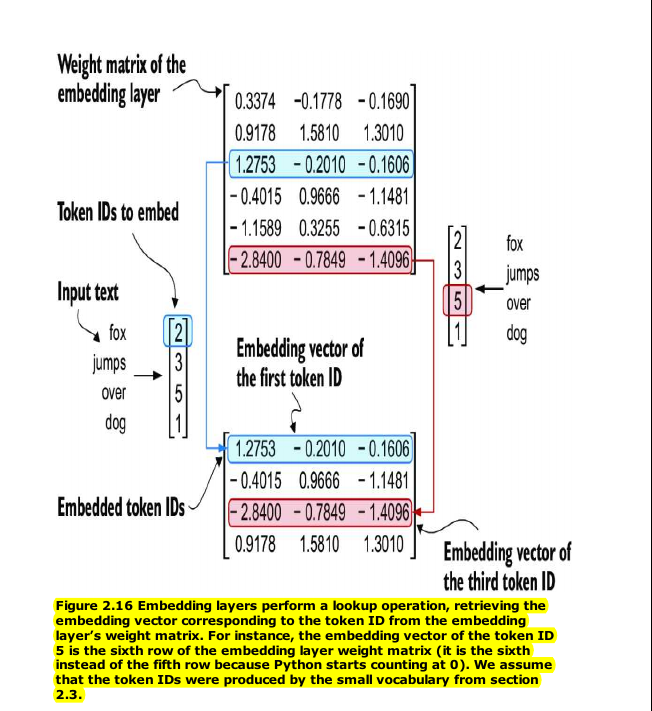  such a nice thing, i neglected it inititally

In [ ]:
token_embedding_layer(inputs).shape

torch.Size([8, 4, 256])

using position embedding, not rotation embedding etc to keep things simple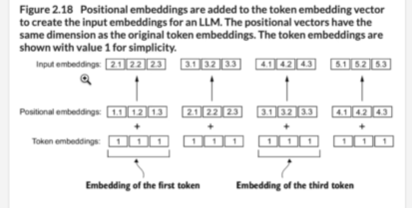

In [ ]:
context_length = max_length

pos_embedding_layer = torch.nn.Embedding(context_length, output_dim)

print(pos_embedding_layer.weight)
print(context_length, output_dim)

Parameter containing:
tensor([[ 0.2560, -0.2347,  0.1276,  ...,  1.7527, -1.0715,  1.0491],
        [ 1.1176, -0.6582, -2.2018,  ..., -1.3537,  0.2875, -0.1196],
        [ 0.7294,  0.5954, -1.3672,  ..., -0.4902, -0.7556, -0.4562],
        [-1.3452, -0.3476, -1.1031,  ..., -0.5272,  0.9858,  1.1967]],
       requires_grad=True)
4 256


In [ ]:
torch.arange(max_length)

tensor([0, 1, 2, 3])

In [ ]:
pos_embedding= pos_embedding_layer(torch.arange(max_length))

In [ ]:
torch.manual_seed(123)
print(pos_embedding.shape)
print(pos_embedding)

torch.Size([4, 256])
tensor([[ 0.2560, -0.2347,  0.1276,  ...,  1.7527, -1.0715,  1.0491],
        [ 1.1176, -0.6582, -2.2018,  ..., -1.3537,  0.2875, -0.1196],
        [ 0.7294,  0.5954, -1.3672,  ..., -0.4902, -0.7556, -0.4562],
        [-1.3452, -0.3476, -1.1031,  ..., -0.5272,  0.9858,  1.1967]],
       grad_fn=<EmbeddingBackward0>)


In [ ]:
hari = [3,2,1,0]

print(pos_embedding_layer(torch.tensor(hari)))

tensor([[-1.3452, -0.3476, -1.1031,  ..., -0.5272,  0.9858,  1.1967],
        [ 0.7294,  0.5954, -1.3672,  ..., -0.4902, -0.7556, -0.4562],
        [ 1.1176, -0.6582, -2.2018,  ..., -1.3537,  0.2875, -0.1196],
        [ 0.2560, -0.2347,  0.1276,  ...,  1.7527, -1.0715,  1.0491]],
       grad_fn=<EmbeddingBackward0>)


In [ ]:
token_embedding_layer(inputs)

tensor([[[ 1.0468, -0.9877,  0.1169,  ..., -0.8248, -1.3581, -0.6504],
         [ 0.2542,  1.0154,  1.1557,  ..., -0.5059,  1.8069, -0.3442],
         [-0.7028,  0.3878,  0.5469,  ...,  0.1031, -0.5147, -0.5559],
         [ 0.4008,  0.8464, -1.2722,  ..., -1.1141,  0.3712,  0.6555]],

        [[ 2.2891, -0.8241,  0.7606,  ..., -0.0713,  1.0773, -1.6102],
         [ 0.5140,  0.6194,  2.1749,  ...,  0.7078,  0.3252,  0.5693],
         [-0.4270, -2.8876, -1.3638,  ..., -0.4342, -0.1795,  1.0636],
         [ 0.0423,  0.4836,  0.2905,  ..., -1.3793,  1.3296,  0.0600]],

        [[ 0.6527, -0.4804,  0.9332,  ..., -1.3699,  1.9664,  1.3115],
         [-1.6443, -0.3151,  0.9135,  ...,  1.7148,  0.0582, -0.6342],
         [ 2.2891, -0.8241,  0.7606,  ..., -0.0713,  1.0773, -1.6102],
         [-1.1005, -1.3176,  0.7631,  ...,  0.1062, -0.1802,  0.0259]],

        ...,

        [[-0.6447, -0.9453,  0.1028,  ..., -0.8401, -2.3965,  0.5825],
         [ 1.0468, -0.9877,  0.1169,  ..., -0.8248, -1.35

In [ ]:
input_embedding= token_embedding_layer(inputs) + pos_embedding